# Hybrid Model: PhoBERT + TF-IDF (with Improvements)

---
## Contents:
1. **Original Hybrid Model** - PhoBERT + TF-IDF (C=1.0, No SMOTE)
2. **Improved Models** - SMOTE + Regularization + XGBoost + Late Fusion

---
## Cải tiến:
1. **SMOTE** - Xử lý class imbalance (Neutral: 458 → 3000)
2. **Regularization** - Giảm C từ 1.0 → 0.1
3. **XGBoost** - Classifier mạnh hơn
4. **Late Fusion** - Kết hợp predictions riêng biệt

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
!pip install transformers torch scikit-learn matplotlib seaborn xgboost imbalanced-learn underthesea -q

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import pickle
import re
import json
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.9.0+cu126
CUDA: True
GPU: Tesla T4


In [24]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [25]:
class Config:
    BASE_DIR = '/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis'
    DATA_DIR = f'{BASE_DIR}/data/processed'
    RESULTS_DIR = f'{BASE_DIR}/results/TF_IDF_Hybrid'
    PHOBERT_MODEL_DIR = f'{BASE_DIR}/results/PhoBERT_Baseline/phobert_baseline_model.pt'
    MODEL_NAME = 'vinai/phobert-base'
    MAX_LENGTH = 256
    BATCH_SIZE = 32
    NUM_CLASSES = 3
    TFIDF_MAX_FEATURES = 5000
    TFIDF_NGRAM_RANGE = (1, 2)
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

config = Config()
os.makedirs(config.RESULTS_DIR, exist_ok=True)
print(f'Results: {config.RESULTS_DIR}')
print(f'Device: {config.DEVICE}')

Results: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/TF_IDF_Hybrid
Device: cuda


In [26]:
def load_data(data_dir, split):
    split_dir = os.path.join(data_dir, split)
    with open(os.path.join(split_dir, 'sents.txt'), 'r', encoding='utf-8') as f:
        texts = [line.strip() for line in f.readlines()]
    with open(os.path.join(split_dir, 'sentiments.txt'), 'r', encoding='utf-8') as f:
        labels = [int(line.strip()) for line in f.readlines()]
    print(f'{split}: {len(texts)} samples')
    return texts, labels

train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

train: 11426 samples
validation: 1583 samples
test: 3166 samples


In [27]:
print('Label distribution:')
for split_name, labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    counter = Counter(labels)
    print(f'{split_name}:')
    for label, count in sorted(counter.items()):
        print(f'  {config.LABEL_MAP[label]}: {count} ({count/len(labels)*100:.1f}%)')

Label distribution:
Train:
  Negative: 5325 (46.6%)
  Neutral: 458 (4.0%)
  Positive: 5643 (49.4%)
Val:
  Negative: 705 (44.5%)
  Neutral: 73 (4.6%)
  Positive: 805 (50.9%)
Test:
  Negative: 1409 (44.5%)
  Neutral: 167 (5.3%)
  Positive: 1590 (50.2%)


---
## 1. Original Hybrid Model (PhoBERT + TF-IDF)
### 1.1 PhoBERT Model

In [28]:
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
print(f'Tokenizer loaded: {config.MODEL_NAME}')

Tokenizer loaded: vinai/phobert-base


In [29]:
class PhoBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.1):
        super(PhoBERTClassifier, self).__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits, pooled_output

    def extract_embeddings(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
            pooled_output = outputs.last_hidden_state[:, 0, :]
        return pooled_output

In [30]:
def load_model_safe(model, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict):
        if 'state_dict' in checkpoint:
            state_dict = checkpoint['state_dict']
        elif 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint
    else:
        state_dict = checkpoint
    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith('module.'):
            new_state_dict[k[7:]] = v
        else:
            new_state_dict[k] = v
    model.load_state_dict(new_state_dict)
    return model

print('Loading PhoBERT Baseline model...')
phobert_model = PhoBERTClassifier(model_name=config.MODEL_NAME, num_classes=config.NUM_CLASSES)
phobert_model = load_model_safe(phobert_model, config.PHOBERT_MODEL_DIR, config.DEVICE)
phobert_model = phobert_model.to(config.DEVICE)
for param in phobert_model.parameters():
    param.requires_grad = False
phobert_model.eval()
print('PhoBERT model loaded and frozen!')

Loading PhoBERT Baseline model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PhoBERT model loaded and frozen!


### 1.2 Dataset Class

In [31]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text, add_special_tokens=True, max_length=self.max_length,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

### 1.3 TF-IDF Feature Extraction

In [32]:
def preprocess_vietnamese(text):
    text = text.lower()
    text = re.sub(r'[^\w\sàáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ]', ' ', text)
    text = ' '.join(text.split())
    return text

train_texts_processed = [preprocess_vietnamese(t) for t in train_texts]
val_texts_processed = [preprocess_vietnamese(t) for t in val_texts]
test_texts_processed = [preprocess_vietnamese(t) for t in test_texts]

print('Creating TF-IDF vectorizer...')
tfidf_vectorizer = TfidfVectorizer(
    max_features=config.TFIDF_MAX_FEATURES,
    ngram_range=config.TFIDF_NGRAM_RANGE,
    min_df=2, max_df=0.95, sublinear_tf=True
)

train_tfidf = tfidf_vectorizer.fit_transform(train_texts_processed)
val_tfidf = tfidf_vectorizer.transform(val_texts_processed)
test_tfidf = tfidf_vectorizer.transform(test_texts_processed)

print(f'TF-IDF train: {train_tfidf.shape}')
print(f'TF-IDF val: {val_tfidf.shape}')
print(f'TF-IDF test: {test_tfidf.shape}')

with open(os.path.join(config.RESULTS_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print('TF-IDF saved!')

Creating TF-IDF vectorizer...
TF-IDF train: (11426, 5000)
TF-IDF val: (1583, 5000)
TF-IDF test: (3166, 5000)
TF-IDF saved!


### 1.4 Extract PhoBERT Embeddings

In [33]:
from tqdm import tqdm

def extract_phobert_embeddings(model, texts, tokenizer, device, batch_size=32):
    model.eval()
    all_embeddings = []
    dataloader = DataLoader(
        SentimentDataset(texts, [0]*len(texts), tokenizer, config.MAX_LENGTH),
        batch_size=batch_size, shuffle=False
    )
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Extracting'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            embeddings = model.extract_embeddings(input_ids, attention_mask)
            all_embeddings.append(embeddings.cpu().numpy())
    return np.vstack(all_embeddings)

print('Extracting PhoBERT embeddings...')
train_phobert_emb = extract_phobert_embeddings(phobert_model, train_texts, tokenizer, config.DEVICE, config.BATCH_SIZE)
val_phobert_emb = extract_phobert_embeddings(phobert_model, val_texts, tokenizer, config.DEVICE, config.BATCH_SIZE)
test_phobert_emb = extract_phobert_embeddings(phobert_model, test_texts, tokenizer, config.DEVICE, config.BATCH_SIZE)
print(f'Train: {train_phobert_emb.shape}, Val: {val_phobert_emb.shape}, Test: {test_phobert_emb.shape}')

Extracting PhoBERT embeddings...


Extracting: 100%|██████████| 99/99 [00:40<00:00,  2.44it/s]

Train: (11426, 768), Val: (1583, 768), Test: (3166, 768)


### 1.5 Combine & Train Original Hybrid

In [34]:
def combine_features(phobert_emb, tfidf_features):
    tfidf_dense = tfidf_features.toarray()
    combined = np.hstack([phobert_emb, tfidf_dense])
    return combined

print('Combining features...')
train_combined = combine_features(train_phobert_emb, train_tfidf)
val_combined = combine_features(val_phobert_emb, val_tfidf)
test_combined = combine_features(test_phobert_emb, test_tfidf)

print(f'Train: {train_combined.shape}, Val: {val_combined.shape}, Test: {test_combined.shape}')

scaler = StandardScaler()
train_combined_scaled = scaler.fit_transform(train_combined)
val_combined_scaled = scaler.transform(val_combined)
test_combined_scaled = scaler.transform(test_combined)

with open(os.path.join(config.RESULTS_DIR, 'feature_scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print('Features scaled!')

Combining features...
Train: (11426, 5768), Val: (1583, 5768), Test: (3166, 5768)
Features scaled!


### 1.6 Train Original Hybrid (C=1.0, No SMOTE)

In [35]:
print('='*50)
print('ORIGINAL HYBRID (C=1.0, No SMOTE)')
print('='*50)

hybrid_model = LogisticRegression(
    multi_class='multinomial', max_iter=1000, random_state=42, n_jobs=-1,
    C=1.0, class_weight='balanced'
)
hybrid_model.fit(train_combined_scaled, train_labels)

train_preds = hybrid_model.predict(train_combined_scaled)
val_preds = hybrid_model.predict(val_combined_scaled)
test_preds = hybrid_model.predict(test_combined_scaled)

train_acc = accuracy_score(train_labels, train_preds)
val_acc = accuracy_score(val_labels, val_preds)
test_acc = accuracy_score(test_labels, test_preds)
train_f1 = f1_score(train_labels, train_preds, average='weighted')
val_f1 = f1_score(val_labels, val_preds, average='weighted')
test_f1 = f1_score(test_labels, test_preds, average='weighted')

print(f'Train - Acc: {train_acc:.4f}, F1: {train_f1:.4f}')
print(f'Val   - Acc: {val_acc:.4f}, F1: {val_f1:.4f}')
print(f'Test  - Acc: {test_acc:.4f}, F1: {test_f1:.4f}')
print('\n' + classification_report(test_labels, test_preds, target_names=['Negative', 'Neutral', 'Positive'], digits=4))

ORIGINAL HYBRID (C=1.0, No SMOTE)
Train - Acc: 0.9999, F1: 0.9999
Val   - Acc: 0.9375, F1: 0.9375
Test  - Acc: 0.9308, F1: 0.9298

              precision    recall  f1-score   support

    Negative     0.9393    0.9553    0.9472      1409
     Neutral     0.6309    0.5629    0.5949       167
    Positive     0.9514    0.9478    0.9496      1590

    accuracy                         0.9308      3166
   macro avg     0.8405    0.8220    0.8306      3166
weighted avg     0.9291    0.9308    0.9298      3166



In [36]:
# Train PhoBERT-only for comparison
print('\nTraining PhoBERT-only for comparison...')
phobert_only = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42, n_jobs=-1)
scaler_p = StandardScaler()
train_p = scaler_p.fit_transform(train_phobert_emb)
test_p = scaler_p.transform(test_phobert_emb)
phobert_only.fit(train_p, train_labels)
phobert_test_preds = phobert_only.predict(test_p)
phobert_test_acc = accuracy_score(test_labels, phobert_test_preds)
phobert_test_f1 = f1_score(test_labels, phobert_test_preds, average='weighted')
print(f'PhoBERT Only - Acc: {phobert_test_acc:.4f}, F1: {phobert_test_f1:.4f}')


Training PhoBERT-only for comparison...
PhoBERT Only - Acc: 0.9283, F1: 0.9262


---
## 2. Improved Models (SMOTE + Regularization + XGBoost + Late Fusion)

### Cải tiến:
1. **SMOTE** - Neutral: 458 → 3000
2. **Regularization** - C: 1.0 → 0.1
3. **XGBoost** - Stronger classifier
4. **Late Fusion** - Separate prediction fusion

### 2.1 SMOTE - Fix Class Imbalance

In [37]:
print('='*50)
print('APPLYING SMOTE')
print('='*50)
print('BEFORE:', Counter(train_labels))

smote = SMOTE(sampling_strategy={0: 5325, 1: 3000, 2: 5643}, random_state=42, k_neighbors=5)
train_combined_smote, train_labels_smote = smote.fit_resample(train_combined, train_labels)

print('AFTER:', Counter(train_labels_smote))
print(f'Shape: {train_combined.shape} -> {train_combined_smote.shape}')
print('SMOTE applied! Neutral: 458 -> 3000')

APPLYING SMOTE
BEFORE: Counter({2: 5643, 0: 5325, 1: 458})
AFTER: Counter({2: 5643, 0: 5325, 1: 3000})
Shape: (11426, 5768) -> (13968, 5768)
SMOTE applied! Neutral: 458 -> 3000


### 2.2 Scale & Train Improved Models

In [38]:
scaler_smote = StandardScaler()
train_combined_smote_scaled = scaler_smote.fit_transform(train_combined_smote)
test_combined_smote_scaled = scaler_smote.transform(test_combined)
improved_results = {}

# MODEL 1: LR (C=0.1) + SMOTE
print('Training LR (C=0.1) + SMOTE...')
lr_improved = LogisticRegression(multi_class='multinomial', max_iter=2000, random_state=42, n_jobs=-1, C=0.1)
lr_improved.fit(train_combined_smote_scaled, train_labels_smote)
lr_preds = lr_improved.predict(test_combined_smote_scaled)
lr_acc = accuracy_score(test_labels, lr_preds)
lr_f1 = f1_score(test_labels, lr_preds, average='weighted')
improved_results['LR (C=0.1) + SMOTE'] = {'accuracy': lr_acc, 'f1': lr_f1}
print(f'Accuracy: {lr_acc:.4f}, F1: {lr_f1:.4f}')

Training LR (C=0.1) + SMOTE...
Accuracy: 0.9311, F1: 0.9302


In [39]:
# MODEL 2: XGBoost + SMOTE
print('\nTraining XGBoost + SMOTE...')
xgb_improved = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, random_state=42, n_jobs=-1, eval_metric='mlogloss',
    use_label_encoder=False, reg_alpha=0.1, reg_lambda=1.0
)
xgb_improved.fit(train_combined_smote_scaled, train_labels_smote)
xgb_preds = xgb_improved.predict(test_combined_smote_scaled)
xgb_acc = accuracy_score(test_labels, xgb_preds)
xgb_f1 = f1_score(test_labels, xgb_preds, average='weighted')
improved_results['XGBoost + SMOTE'] = {'accuracy': xgb_acc, 'f1': xgb_f1}
print(f'Accuracy: {xgb_acc:.4f}, F1: {xgb_f1:.4f}')


Training XGBoost + SMOTE...
Accuracy: 0.9327, F1: 0.9319


In [40]:
# MODEL 3: Late Fusion + SMOTE
print('\nTraining Late Fusion + SMOTE...')

# Scale separately
scaler_phobert_lf = StandardScaler()
train_phobert_lf = scaler_phobert_lf.fit_transform(train_phobert_emb)
test_phobert_lf = scaler_phobert_lf.transform(test_phobert_emb)

scaler_tfidf_lf = StandardScaler()
train_tfidf_lf = scaler_tfidf_lf.fit_transform(train_tfidf.toarray())
test_tfidf_lf = scaler_tfidf_lf.transform(test_tfidf.toarray())

# Apply SMOTE separately (CỰNG QUAN TR�NG: phải dùng cùng random_state để đồng bộ)
train_phobert_smote_lf, train_labels_smote_lf = smote.fit_resample(train_phobert_lf, train_labels)
train_tfidf_smote_lf, train_labels_smote_lf = smote.fit_resample(train_tfidf_lf, train_labels)

# Train separate models (cùng dùng train_labels_smote_lf)
phobert_lf = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42, n_jobs=-1, C=0.1)
phobert_lf.fit(train_phobert_smote_lf, train_labels_smote_lf)
phobert_probs_lf = phobert_lf.predict_proba(test_phobert_lf)

tfidf_lf = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42, n_jobs=-1, C=0.1)
tfidf_lf.fit(train_tfidf_smote_lf, train_labels_smote_lf)
tfidf_probs_lf = tfidf_lf.predict_proba(test_tfidf_lf)

# Fusion
weights = {'phobert': 0.7, 'tfidf': 0.3}
fused_probs = weights['phobert'] * phobert_probs_lf + weights['tfidf'] * tfidf_probs_lf
fused_preds = np.argmax(fused_probs, axis=1)
fused_acc = accuracy_score(test_labels, fused_preds)
fused_f1 = f1_score(test_labels, fused_preds, average='weighted')
improved_results['Late Fusion + SMOTE'] = {'accuracy': fused_acc, 'f1': fused_f1}
print(f'Weights: PhoBERT={weights["phobert"]}, TF-IDF={weights["tfidf"]}')
print(f'Accuracy: {fused_acc:.4f}, F1: {fused_f1:.4f}')


Training Late Fusion + SMOTE...
Weights: PhoBERT=0.7, TF-IDF=0.3
Accuracy: 0.9302, F1: 0.9286


### 2.3 Compare All Models

In [41]:
import pandas as pd

print('\n' + '='*60)
print('COMPLETE MODEL COMPARISON')
print('='*60)

all_comparison = [
    {'Model': 'Original Hybrid (C=1.0)', 'Test Accuracy': test_acc, 'Test F1': test_f1, 'Type': 'Original'},
    {'Model': 'PhoBERT Only', 'Test Accuracy': phobert_test_acc, 'Test F1': phobert_test_f1, 'Type': 'Baseline'}
]

for name, res in improved_results.items():
    all_comparison.append({'Model': name, 'Test Accuracy': res['accuracy'], 'Test F1': res['f1'], 'Type': 'Improved'})

comparison_df = pd.DataFrame(all_comparison).sort_values('Test F1', ascending=False)
print(comparison_df.to_string(index=False))

print('\n' + '='*60)
print('IMPROVEMENTS OVER ORIGINAL')
print('='*60)
for _, row in comparison_df.iterrows():
    if row['Type'] == 'Improved':
        print(f"{row['Model']}:")
        print(f"  Accuracy: {row['Test Accuracy']:.4f} ({(row['Test Accuracy']-test_acc)*100:+.2f}%)")
        print(f"  F1: {row['Test F1']:.4f} ({(row['Test F1']-test_f1)*100:+.2f}%)")


COMPLETE MODEL COMPARISON
                  Model  Test Accuracy  Test F1     Type
        XGBoost + SMOTE       0.932723 0.931898 Improved
     LR (C=0.1) + SMOTE       0.931143 0.930212 Improved
Original Hybrid (C=1.0)       0.930828 0.929828 Original
    Late Fusion + SMOTE       0.930196 0.928623 Improved
           PhoBERT Only       0.928301 0.926190 Baseline

IMPROVEMENTS OVER ORIGINAL
XGBoost + SMOTE:
  Accuracy: 0.9327 (+0.19%)
  F1: 0.9319 (+0.21%)
LR (C=0.1) + SMOTE:
  Accuracy: 0.9311 (+0.03%)
  F1: 0.9302 (+0.04%)
Late Fusion + SMOTE:
  Accuracy: 0.9302 (-0.06%)
  F1: 0.9286 (-0.12%)


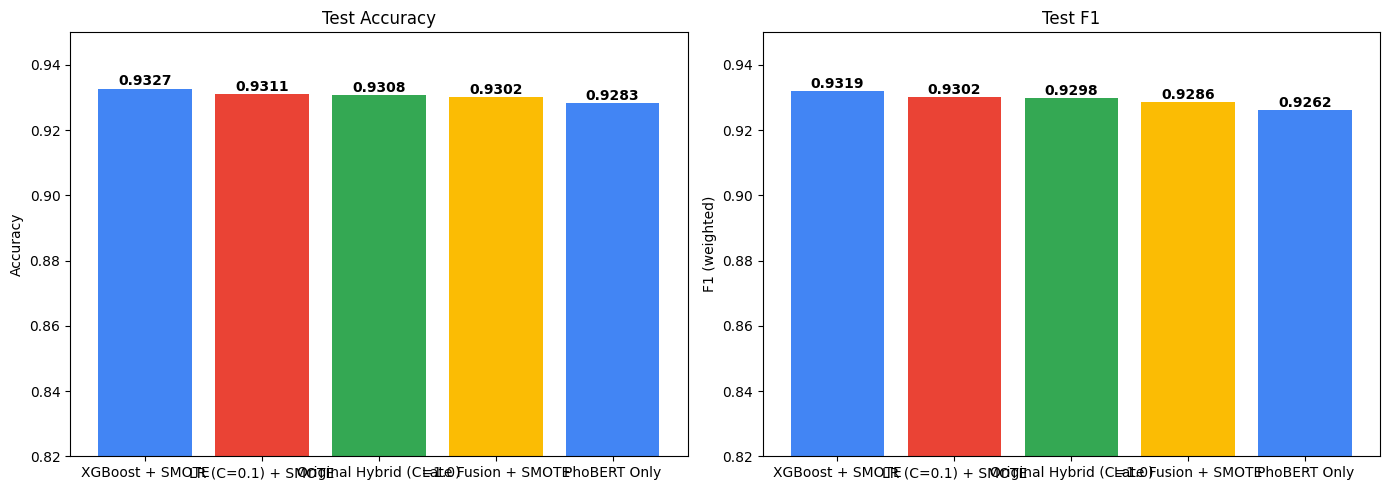

In [42]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4285F4', '#EA4335', '#34A853', '#FBBC04']
axes[0].bar(comparison_df['Model'], comparison_df['Test Accuracy'], color=colors[:len(comparison_df)])
axes[0].set_title('Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.82, 0.95)
for i, v in enumerate(comparison_df['Test Accuracy']):
    axes[0].text(i, v+0.001, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].bar(comparison_df['Model'], comparison_df['Test F1'], color=colors[:len(comparison_df)])
axes[1].set_title('Test F1')
axes[1].set_ylabel('F1 (weighted)')
axes[1].set_ylim(0.82, 0.95)
for i, v in enumerate(comparison_df['Test F1']):
    axes[1].text(i, v+0.001, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'all_models_comparison.png'), dpi=150)
plt.show()

### 2.4 Save Improved Models

In [43]:
IMPROVED_DIR = f'{config.RESULTS_DIR}_Improved'
os.makedirs(IMPROVED_DIR, exist_ok=True)

with open(os.path.join(IMPROVED_DIR, 'lr_improved.pkl'), 'wb') as f:
    pickle.dump(lr_improved, f)
with open(os.path.join(IMPROVED_DIR, 'xgb_improved.pkl'), 'wb') as f:
    pickle.dump(xgb_improved, f)
with open(os.path.join(IMPROVED_DIR, 'late_fusion.pkl'), 'wb') as f:
    pickle.dump({'phobert': phobert_lf, 'tfidf': tfidf_lf, 'weights': weights}, f)

comparison_df.to_csv(os.path.join(IMPROVED_DIR, 'comparison.csv'), index=False)

print(f'\nAll saved to: {IMPROVED_DIR}')
print(f'Best Model: {comparison_df.iloc[0]["Model"]}')
print(f'Best F1: {comparison_df.iloc[0]["Test F1"]:.4f}')


All saved to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/TF_IDF_Hybrid_Improved
Best Model: XGBoost + SMOTE
Best F1: 0.9319
